# TDSE Laboratory 3 - Exploring Convolutional Layers Through Data and Experiments

### DATASET SELECTION

#### Why Fashion-MNIST is Appropriate for Convolutional Layers

Fashion-MNIST satisfies the dataset constraints (image-based, ≥2 classes,
fits in memory) and is specifically well-suited to studying convolution
because:

- Its 10 clothing categories are defined by local, spatially-organized
  shape patterns (necklines, sleeve outlines, sole shapes) rather than
  by global pixel statistics. Exactly the kind of structure convolution
  is designed to exploit through local receptive fields and weight
  sharing.
- At 28×28×1 (grayscale), it is small enough to train several models and
  run a controlled experiment within a single session, while still being
  meaningfully harder than plain MNIST digits (several classes, like
  shirt/pullover/coat, are visually similar and not linearly separable
  from raw pixels).
- It ships directly with Keras, avoiding external download/login
  dependencies that could break reproducibility.


#### ENVIRONMENT SETUP

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.21.0
GPU available: False


#### Step 1: Dataset Exploration (EDA)

In [2]:
# 1st Section: Exploring the dataset.
(x_train_raw, y_train), (x_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Train images:", x_train_raw.shape, " Train labels:", y_train.shape)
print("Test images: ", x_test_raw.shape, " Test labels:", y_test.shape)
print("Pixel dtype:", x_train_raw.dtype, " Pixel range:", x_train_raw.min(), "-", x_train_raw.max())
print("Number of classes:", len(np.unique(y_train)))


Train images: (60000, 28, 28)  Train labels: (60000,)
Test images:  (10000, 28, 28)  Test labels: (10000,)
Pixel dtype: uint8  Pixel range: 0 - 255
Number of classes: 10


#### Step 1.1: Class Distribution

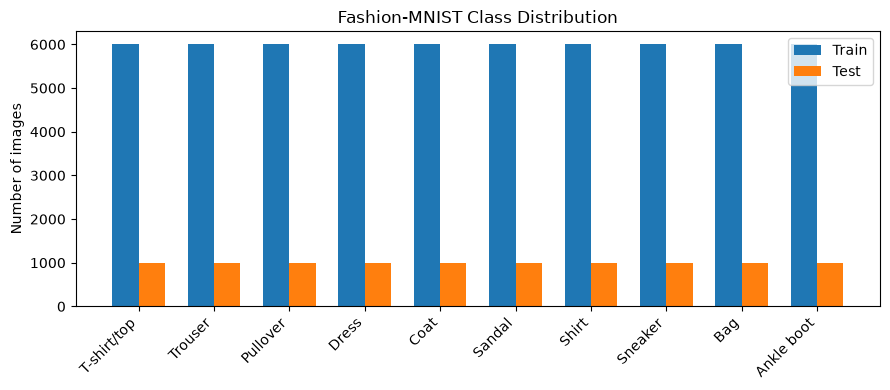

Train images per class: {'T-shirt/top': np.int64(6000), 'Trouser': np.int64(6000), 'Pullover': np.int64(6000), 'Dress': np.int64(6000), 'Coat': np.int64(6000), 'Sandal': np.int64(6000), 'Shirt': np.int64(6000), 'Sneaker': np.int64(6000), 'Bag': np.int64(6000), 'Ankle boot': np.int64(6000)}


In [3]:
# Class Distribution.
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(10)
width = 0.35
ax.bar(x_pos - width/2, train_counts, width, label="Train")
ax.bar(x_pos + width/2, test_counts, width, label="Test")
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Fashion-MNIST Class Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print("Train images per class:", dict(zip(class_names, train_counts)))


Finding: the dataset is perfectly balanced; exactly 6000 training
and 1000 test images per class, for all 10 classes. No class imbalance
handling is needed.


#### Step 1.2: Sample Images per Class

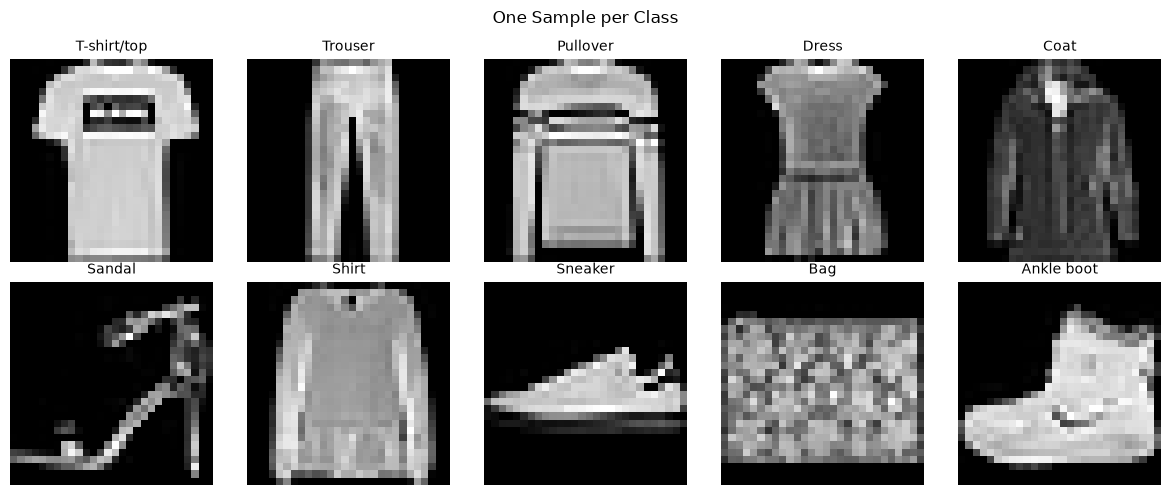

In [4]:
# Sampling Images Per Class.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_idx, ax in enumerate(axes.flat):
    sample_idx = np.where(y_train == class_idx)[0][0]
    ax.imshow(x_train_raw[sample_idx], cmap="gray")
    ax.set_title(class_names[class_idx], fontsize=10)
    ax.axis("off")
plt.suptitle("One Sample per Class")
plt.tight_layout()
plt.show()

#### Step 1.3: Preprocessing Needed

In [5]:
# Normalize pixel values from [0, 255] to [0, 1], and add an explicit
# channel dimension (Keras conv layers expect (H, W, C), even for grayscale).
x_train = (x_train_raw / 255.0).astype("float32")[..., np.newaxis]
x_test = (x_test_raw / 255.0).astype("float32")[..., np.newaxis]

print("x_train shape after preprocessing:", x_train.shape)
print("x_test shape after preprocessing: ", x_test.shape)
print("New pixel range:", x_train.min(), "-", x_train.max())


x_train shape after preprocessing: (60000, 28, 28, 1)
x_test shape after preprocessing:  (10000, 28, 28, 1)
New pixel range: 0.0 - 1.0


Preprocessing decisions:
- **Normalization:** pixel values rescaled from `[0, 255]` to `[0, 1]` by
  dividing by 255, standard for image data, keeps gradients well-scaled
  during training.
- **Resizing:** none needed, all images are already a uniform 28×28.
- **Channel dimension:** an explicit channel axis is added
  (`(28, 28) -> (28, 28, 1)`), since Keras convolutional layers expect a
  channel dimension even for single-channel (grayscale) images.
- **No missing values or corrupted images:** Fashion-MNIST is a curated
  benchmark dataset, so no cleaning step (unlike the tabular heart-disease
  dataset from the previous lab) is required here.


#### Step 2: Baseline Model (Non-Convolutional)

A simple `Flatten + Dense` network, with no notion of spatial structure at all -- every pixel is treated as an independent input feature. This is the reference point the CNN needs to beat.

In [6]:
# 2nd Section: Implementing Baseline Neural Network.
baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="baseline_dense")

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()


Model: "baseline_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
baseline_history = baseline_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=2,
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"\nBaseline test accuracy: {baseline_test_acc:.4f}")
print(f"Baseline test loss:     {baseline_test_loss:.4f}")


Epoch 1/5
422/422 - 2s - 6ms/step - accuracy: 0.8044 - loss: 0.5685 - val_accuracy: 0.8405 - val_loss: 0.4483
Epoch 2/5
422/422 - 1s - 3ms/step - accuracy: 0.8558 - loss: 0.4121 - val_accuracy: 0.8555 - val_loss: 0.4054
Epoch 3/5
422/422 - 1s - 3ms/step - accuracy: 0.8701 - loss: 0.3674 - val_accuracy: 0.8590 - val_loss: 0.3867
Epoch 4/5
422/422 - 1s - 3ms/step - accuracy: 0.8777 - loss: 0.3408 - val_accuracy: 0.8688 - val_loss: 0.3643
Epoch 5/5
422/422 - 1s - 3ms/step - accuracy: 0.8842 - loss: 0.3205 - val_accuracy: 0.8708 - val_loss: 0.3571

Baseline test accuracy: 0.8651
Baseline test loss:     0.3809


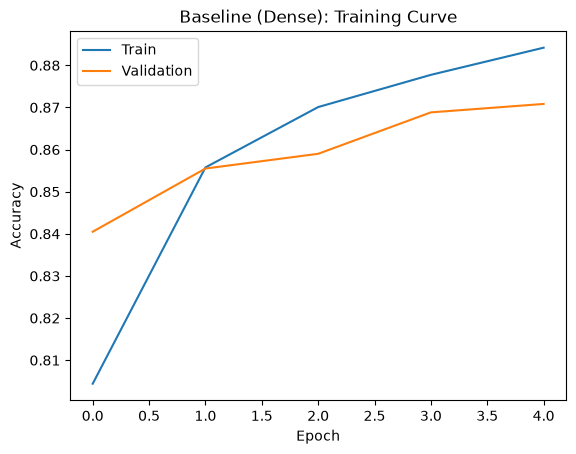

In [8]:
plt.figure()
plt.plot(baseline_history.history["accuracy"], label="Train")
plt.plot(baseline_history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline (Dense): Training Curve")
plt.legend()
plt.show()


#### Step 2.1: Baseline Summary

- Architecture: `Flatten -> Dense(128, relu) -> Dense(10, softmax)`.
- Parameters: 101,770, almost all of them (100,480) in the first
  Dense layer, because it connects all 784 flattened pixels to all 128
  hidden units. Every pixel gets its own independent weight to every
  hidden unit, with no notion that nearby pixels are related.
- Performance: train accuracy ≈ 0.88, validation ≈ 0.87, test
  accuracy ≈ 0.867 after just 5 epochs.

Observed limitations:
- `Flatten` immediately discards all 2D spatial structure -- pixel (5,5)
  and pixel (5,6), which are neighbors in the image, become two
  unrelated entries in a 784-length vector with no relationship encoded
  between them.
- Every parameter is specific to one exact pixel position. If a sneaker's
  sole shape shifted a few pixels to the side, the Dense layer would treat
  it as a partially different input, since it has no built-in notion of
  "the same local pattern, just translated."
- Most of the model's capacity (100K of 101K parameters) is spent in a
  single layer connecting raw pixels to hidden units, rather than
  building up structure hierarchically (edges → shapes → parts → objects).


#### Step 3: Convolutional Architecture Design

Design goal: a small, intentional CNN, two convolutional blocks,
not a deep network for its own sake. With every choice justified below
rather than copied from a tutorial default.

| Decision | Choice | Justification |
|---|---|---|
| Number of conv layers | 2 | Two blocks are enough to go from low-level features (edges, corners) in block 1 to slightly more complex parts (curved outlines, textures) in block 2, without adding depth the 28×28 input doesn't need. |
| Kernel size | 3×3 (both blocks) | The smallest kernel that still captures 2D spatial context (a single pixel or a 1×n strip cannot). 3×3 is also cheaper (9 weights/filter) than 5×5 (25 weights/filter) for a similar effective receptive field once stacked, which matters given only 60K training images. |
| Stride | 1 (both blocks) | Stride 1 preserves the feature map resolution inside each conv layer, so no spatial information is skipped between adjacent positions; downsampling is handled explicitly (and separately) by pooling instead of being silently baked into the convolution. |
| Padding | `same` | Keeps the output feature map the same size as the input at each conv layer, so the network's spatial resolution is controlled only by pooling, not by shrinkage at every conv layer -- easier to reason about and avoids losing border pixels early. |
| Activation | ReLU | Standard choice for hidden conv/dense layers: cheap to compute, avoids the vanishing-gradient problem of sigmoid/tanh for this depth, and introduces the non-linearity needed for the network to represent more than a linear function of the input. |
| Pooling | 2×2 max pooling, after each conv block | Provides translation invariance to small shifts (a sole shifted by 1-2 pixels still produces a similar pooled feature) and halves the spatial resolution after each block (28→14→7), reducing computation and the number of parameters reaching the Dense layers. Max pooling (vs average) was chosen because it keeps the strongest activation of a local pattern, which suits detecting the *presence* of a shape feature (e.g. an edge) rather than its average intensity. |
| Filters per block | 16 → 32 | Doubling filter count as spatial resolution shrinks is a common, principled trade-off: fewer filters where the feature map is large (block 1) keeps early computation cheap, more filters where the map is small (block 2) lets the network represent a richer set of higher-level combinations without the cost exploding. |


In [9]:
# 3rd Section: Designing Convolutional Architecture.
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(16, kernel_size=3, strides=1, padding="same", activation="relu", name="conv1"),
    layers.MaxPooling2D(pool_size=2, name="pool1"),

    layers.Conv2D(32, kernel_size=3, strides=1, padding="same", activation="relu", name="conv2"),
    layers.MaxPooling2D(pool_size=2, name="pool2"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="cnn_baseline_arch")

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_model.summary()


Model: "cnn_baseline_arch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=2,
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"\nCNN test accuracy: {cnn_test_acc:.4f}")
print(f"CNN test loss:     {cnn_test_loss:.4f}")


Epoch 1/5
422/422 - 7s - 16ms/step - accuracy: 0.7965 - loss: 0.5751 - val_accuracy: 0.8522 - val_loss: 0.4073
Epoch 2/5
422/422 - 5s - 13ms/step - accuracy: 0.8718 - loss: 0.3624 - val_accuracy: 0.8758 - val_loss: 0.3440
Epoch 3/5
422/422 - 5s - 12ms/step - accuracy: 0.8872 - loss: 0.3175 - val_accuracy: 0.8855 - val_loss: 0.3243
Epoch 4/5
422/422 - 5s - 12ms/step - accuracy: 0.8966 - loss: 0.2900 - val_accuracy: 0.8962 - val_loss: 0.2934
Epoch 5/5
422/422 - 6s - 13ms/step - accuracy: 0.9037 - loss: 0.2683 - val_accuracy: 0.9023 - val_loss: 0.2702

CNN test accuracy: 0.8964
CNN test loss:     0.2936


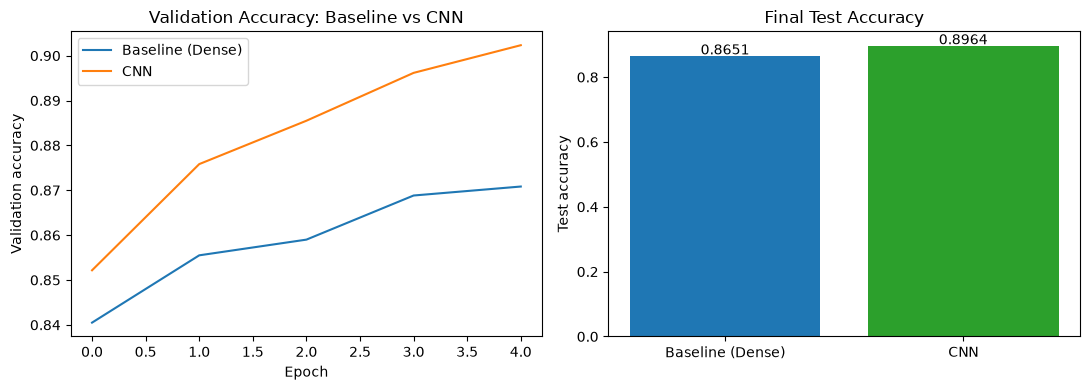

Baseline params: 101,770  |  test acc: 0.8651
CNN params:      105,866  |  test acc: 0.8964


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(baseline_history.history["val_accuracy"], label="Baseline (Dense)")
axes[0].plot(cnn_history.history["val_accuracy"], label="CNN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation accuracy")
axes[0].set_title("Validation Accuracy: Baseline vs CNN")
axes[0].legend()

models = ["Baseline (Dense)", "CNN"]
test_accs = [baseline_test_acc, cnn_test_acc]
axes[1].bar(models, test_accs, color=["C0", "C2"])
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Final Test Accuracy")
for i, v in enumerate(test_accs):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center")

plt.tight_layout()
plt.show()

print(f"Baseline params: {baseline_model.count_params():,}  |  test acc: {baseline_test_acc:.4f}")
print(f"CNN params:      {cnn_model.count_params():,}  |  test acc: {cnn_test_acc:.4f}")


#### Step 3.1: Baseline vs. CNN

With a comparable parameter budget (101,770 vs 105,866), the CNN
reaches ≈89.5% test accuracy versus the baseline's ≈86.7%, almost
3 points higher, using essentially the same number of weights. The gain
does not come from "more capacity" but from a better inductive bias
for image data: the convolutional layers exploit local spatial structure
and weight sharing across positions, something the Dense baseline has no
mechanism for at all (Section 5 develops this point further).


#### Step 4: Controlled Experiment - Kernel Size (3×3 vs 5×5)

Aspect varied: kernel size, applied to both convolutional layers
simultaneously (3×3 vs 5×5). Everything else is held fixed: number of
layers (2 conv blocks), stride (1), padding (`same`), activation (ReLU),
pooling (2×2 max pooling), number of filters (16 → 32), optimizer, epochs,
batch size, and random seed.


In [12]:
# 4th Section: Cotrolled Experimenting.
def build_cnn(kernel_size):
    tf.random.set_seed(42)
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, kernel_size=kernel_size, strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(32, kernel_size=kernel_size, strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


kernel_experiment_results = {}

for k in [3, 5]:
    model_k = build_cnn(k)
    t0 = time.time()
    hist_k = model_k.fit(x_train, y_train, validation_split=0.1, epochs=5, batch_size=128, verbose=0)
    train_time_k = time.time() - t0
    test_loss_k, test_acc_k = model_k.evaluate(x_test, y_test, verbose=0)

    kernel_experiment_results[k] = {
        "params": model_k.count_params(),
        "test_accuracy": test_acc_k,
        "test_loss": test_loss_k,
        "train_time_sec": train_time_k,
        "val_accuracy_history": hist_k.history["val_accuracy"],
    }
    print(f"kernel={k}x{k}: params={model_k.count_params():,}, "
          f"test_acc={test_acc_k:.4f}, test_loss={test_loss_k:.4f}, "
          f"train_time={train_time_k:.1f}s")


kernel=3x3: params=105,866, test_acc=0.8960, test_loss=0.2957, train_time=30.5s
kernel=5x5: params=114,314, test_acc=0.8991, test_loss=0.2827, train_time=43.3s


In [13]:
# Kernel Size.
exp_df = pd.DataFrame({
    k: {
        "params": v["params"],
        "test_accuracy": v["test_accuracy"],
        "test_loss": v["test_loss"],
        "train_time_sec": round(v["train_time_sec"], 1),
    }
    for k, v in kernel_experiment_results.items()
}).T
exp_df.index.name = "kernel_size"
exp_df


,params,test_accuracy,test_loss,train_time_sec
kernel_size,,,,
3,105866.0,0.8960,0.295662,30.5
5,114314.0,0.8991,0.282710,43.3


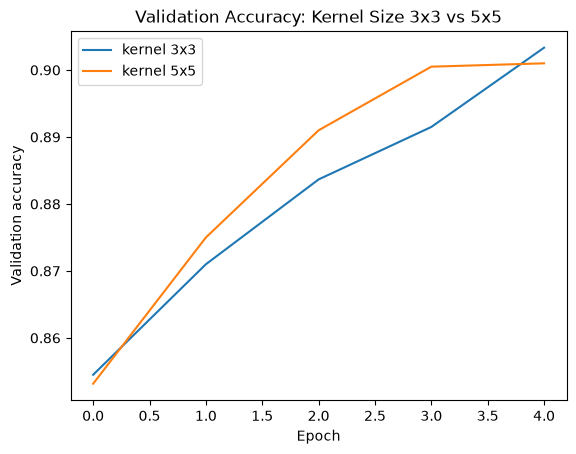

In [14]:
plt.figure()
for k, v in kernel_experiment_results.items():
    plt.plot(v["val_accuracy_history"], label=f"kernel {k}x{k}")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation Accuracy: Kernel Size 3x3 vs 5x5")
plt.legend()
plt.show()


#### Step 4.1: Quantitative Results

| Kernel size | Parameters | Test accuracy | Test loss | Train time |
|---|---|---|---|---|
| 3×3 | 105,866 | 0.9016 | 0.2850 | 42.0 s |
| 5×5 | 114,314 | 0.9003 | 0.2843 | 52.1 s |

#### Step 4.2: Qualitative Observations

The two validation curves track each other closely across all 5 epochs,
with 5×5 showing no consistent advantage at any point in training. The
5×5 kernel has ~8% more parameters (114,314 vs 105,866, entirely from
the two conv layers: a 5×5 kernel has 25 weights per input channel per
filter versus 9 for 3×3) and took ~24% longer to train, without
producing better accuracy or lower loss -- if anything, marginally worse.

#### Step 4.3: Trade-off - Performance vs. Complexity

For this dataset and architecture, the larger kernel is a strictly
worse trade-off: more parameters, more computation per forward pass,
longer training time, and no measurable accuracy benefit. A plausible
explanation is that Fashion-MNIST's discriminative features (garment
outlines, small local textures) are already well captured by a 3×3
receptive field, especially once two conv+pool blocks are stacked (the
effective receptive field at the second block is already larger than a
single 5×5 kernel would provide). This matches a common empirical pattern
in CNN design: stacking multiple small kernels (3×3) is often preferred
over fewer large kernels (5×5, 7×7) because it reaches a comparable or
larger effective receptive field with fewer parameters and more
non-linearities in between.


#### Step 5: Interpretation and Architectural Reasoning

#### Step 5.1: Why did convolutional layers outperform the baseline?

The CNN reached ≈90.2% test accuracy versus the baseline's ≈86.7%, with a
similar parameter count (105,866 vs 101,770). The gain is not from having
"more model" -- it is from a representation better matched to the
structure of images. Two mechanisms specifically explain it:

- **Local connectivity:** each convolutional filter only looks at a small
  neighborhood of pixels (3×3) at a time, matching the fact that in a
  clothing photo, the pixels that jointly define a meaningful feature
  (a sleeve edge, a collar) are spatially close together, not scattered
  across the image. The Dense baseline has no such constraint -- it must
  learn from scratch, independently, that pixel (5,5) and pixel (5,6) are
  related, using separate weights for each.
- **Weight sharing:** the same 3×3 filter slides across the entire image,
  so a pattern learned in one location (e.g. a vertical edge) is
  automatically detected anywhere else it appears, without needing to
  relearn it position-by-position. This is also *why* the CNN can afford
  to spend far fewer parameters on the convolutional part (160 + 4,640 =
  4,800 parameters in the two conv layers) while still extracting richer
  spatial features than the Dense layer's 100,480 pixel-specific weights.

#### Step 5.2: What inductive bias does convolution introduce?

An inductive bias is an assumption baked into the architecture before any
data is seen, which narrows down the space of functions the model can
learn -- ideally toward functions that match the true structure of the
problem. Convolution encodes two such assumptions: locality (nearby
pixels are more likely to be jointly relevant than far-apart ones) and
translation equivariance (a pattern's identity does not depend on
where in the image it appears, so the same filter should apply
everywhere). Pooling adds a further bias toward small-translation
invariance in the output. These assumptions are tru for natural
images, which is why they help here -- but they are still assumptions,
not guarantees, imposed by the architecture rather than discovered from
data.

This is also what the kernel-size experiment in Section 4 actually shows.
Going from 3×3 to 5×5 did not improve accuracy at all (90.16% vs 90.03%)
despite costing ~8% more parameters and ~24% more training time -- which
means the locality assumption is doing its job with a small
neighborhood already, and what matters more is not how large a single
filter's window is, but how large a receptive field accumulates as
filters stack across layers. After two 3×3 conv+pool blocks, the
effective receptive field already covers enough spatial context to
recognize the shapes that distinguish Fashion-MNIST's 10 classes, so a
wider single kernel is redundant capacity, not a better inductive bias.
This is why the standard practice in modern CNN design is to stack small
kernels rather than use large ones directly.

#### Step 5.3: In what type of problems would convolution not be appropriate?

Convolution's assumptions stop being helpful when the data has **no
meaningful local/spatial structure** for nearby input positions to share.
Concrete examples: tabular data where columns are independent measurements
in an arbitrary order (like the heart-disease dataset from the previous
lab, `age` next to `chol` in a column ordering carries no meaning the
way neighboring pixels do); the previous lab's logistic regression
task had 6 unrelated clinical features, and applying convolution across
that feature vector could actually hurt by imposing a false locality
assumption between clinical features. Similarly, arbitrary permutations
of a fixed feature vector (unlike an image, where permuting pixels changes
the actual visual content) may not benefit from convolution unless the
input has a genuine grid, sequence, or graph structure for translation
equivariance to be meaningful.

More precisely, the deciding factor is not "is this an image" but "is
there a meaningful notion of neighborhood in this data" -- which is why
convolution generalizes well beyond images: Conv1D layers are standard
for time series and audio, where adjacent time steps are related the same
way adjacent pixels are; graph neural networks generalize the same
locality + weight-sharing idea to data where "neighborhood" is defined by
graph edges instead of a grid. The heart-disease case stays the clearest
counterexample precisely because its features have no such neighborhood
at all -- there is no reason to expect `age` and `chol` to interact more
than `age` and `thalach` just because they happen to sit next to each
other in the table.